In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report


In [3]:

import os
import numpy as np
import pandas as pd

file_path = os.path.join('data', 'data_final_kingcounty_houses.csv')
data_final = pd.read_csv(file_path)


### Split the data into training and testing sets (80% train, 20% test).

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Split BEFORE scaling

X = data_final.drop('price', axis=1)
y = data_final['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Initialize the Scaler (Z-Transform)

scaler = StandardScaler()

# Step 3: Fit and Transform the TRAIN set

X_train_scaled = scaler.fit_transform(X_train)

# Step 4: ONLY Transform the TEST set

X_test_scaled = scaler.transform(X_test)

## Baseline model 1: Linear Regression (-> Lasso/Ridge (Greg))

In [5]:
from sklearn.linear_model import LinearRegression

linreg_model = LinearRegression()
linreg_model.fit(X_train, y_train)
ypred_test_linreg = linreg_model.predict(X_test)
ypred_train_linreg = linreg_model.predict(X_train)


## Baseline model 2: Decision tree

In [6]:
from sklearn.tree import DecisionTreeRegressor

dectree_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dectree_model.fit(X_train, y_train)
ypred_test_dectree = dectree_model.predict(X_test)
ypred_train_dectree = dectree_model.predict(X_train)

## Baseline model 3: XGBoost (no hyperparameter tuning)

In [7]:
import xgboost as xgb

xgb_reg = xgb.XGBRegressor(random_state=42)
xgb_reg.fit(X_train, y_train)
ypred_test_xgb = xgb_reg.predict(X_test)
ypred_train_xgb = xgb_reg.predict(X_train)

In [8]:
# Dataframe with rows Linear Regression, Decision Tree Regressor and XGBoost
# columns: accuracy_train, accuracy_test, MAE_train, MAE_test, R2_train, R2_test

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_train, ypred_train, y_test, ypred_test):
    return {
        "MAE_train": mean_absolute_error(y_train, ypred_train),
        "MAE_test": mean_absolute_error(y_test, ypred_test),
        "RMSE_train": np.sqrt(mean_squared_error(y_train, ypred_train)),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, ypred_test)),
        "R²_train": r2_score(y_train, ypred_train),
        "R²_test": r2_score(y_test, ypred_test),
        }

results = pd.DataFrame({
    "Linear Regression": evaluate(y_train, ypred_train_linreg, y_test, ypred_test_linreg),
    "Decision Tree": evaluate(y_train, ypred_train_dectree, y_test, ypred_test_dectree),
    "XGBoost": evaluate(y_train, ypred_train_xgb, y_test, ypred_test_xgb)
}).T

results

,MAE_train,MAE_test,RMSE_train,RMSE_test,R²_train,R²_test
Linear Regression,124965.270472,127658.698694,198915.653485,213981.920064,0.697146,0.697121
Decision Tree,68354.620000,96288.026514,107155.721147,194658.782939,0.912113,0.749353
XGBoost,38772.507323,70340.609854,54755.021081,138644.721076,0.977052,0.872848


### 1 - Random Forest Regressor - Basic 

In [19]:
rfr_basic = RandomForestRegressor(n_estimators=100,random_state=42)
rfr_basic.fit(X_train, y_train)
y_pred_train_rfr_basic = rfr_basic.predict(X_train)
y_pred_test_rfr_basic = rfr_basic.predict(X_test)

- 1.1 R2 & MAE 

In [52]:
mae_basic = mean_absolute_error(y_train, y_pred_train_rfr_basic)
mse_basic = np.sqrt(mean_squared_error(y_test, y_pred_test_rfr_basic))
r2_test_basic = r2_score(y_test, y_pred_test_rfr_basic)
r2_train_basic = r2_score(y_train, y_pred_train_rfr_basic)
print(f"MAE Basic: {mae_basic:.2f}")
print(f"RMSE basic: {mse_basic:.2f}")
print(f"R² Basic Test: {r2_test_basic:.4f}")
print(f"R² Basic Train: {r2_train_basic:.4f}")


MAE Basic: 25847.56
RMSE basic: 148960.90
R² Basic Test: 0.8532
R² Basic Train: 0.9832


### 2 - Random Forest Regressor - Light parameters revision 


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# 1. Initialize Random Forest
rf_basic = RandomForestRegressor(random_state=42)

# 2. Define Hyperparameter Grid
param_grid = {
    'n_estimators': [100, 200],      # Number of trees
    'max_depth': [10, 20, None],     # Depth of trees
    'min_samples_split': [2, 5]      # Samples needed to split a node
}

# 3. Perform Hyperparameter Tuning
grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid, 
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2)

grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", grid_search.best_params_)

# Best model
best_rf = grid_search.best_estimator_

# Evaluate on test set
y_pred = best_rf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Test MSE:", mse)



# Best model
light_rf = grid_search.best_estimator_

# Predict
y_pred_train_rfr_light = best_rf.predict(X_train)
y_pred_test_rfr_light = best_rf.predict(X_test)



Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Test MSE: 21782128115.296314


In [ ]:
# Evaluate on test set
mae_light = mean_absolute_error(y_train, y_pred_train_rfr_light)
mse_light = np.sqrt(mean_squared_error(y_test, y_pred_test_rfr_light))
r2_test_light = r2_score(y_test, y_pred_test_rfr_light)
r2_train_light = r2_score(y_train, y_pred_train_rfr_light)
print(f"MAE Light: {mae_light:.2f}")
print(f"RMSE Light: {mse_light:.2f}")
print(f"R² Test Light: {r2_test_light:.4f}")
print(f"R² Train Light: {r2_train_light:.4f}")



MAE Light: 25637.55
RMSE Light: 147587.70
R² Test Light: 0.8559
R² Train Light: 0.9830


### 3 - Random Forest Regressor - Best parameters revision 

In [25]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Initialize Random Forest
rf_best = RandomForestRegressor(random_state=42)


# Define parameter distribution for sampling
param_dist = {
    'n_estimators': [80,90,100, 200, 300, 500],   # number of trees
    'max_depth': [None, 10, 20, 30],        # tree depth
    'min_samples_split': [2, 5, 10],        # min samples to split
    'min_samples_leaf': [1, 2, 4],          # min samples per leaf
    'max_features': ['sqrt', 'log2', None]  # number of features per split
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=rf_best,
    param_distributions=param_dist,
    n_iter=200,                 # number of random combinations to try
    cv=3,                      # 3-fold cross-validation (faster than 5)
    scoring='neg_mean_squared_error',
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
    random_state=42
)

# Fit randomized search
random_search.fit(X_train, y_train)

# Best parameters
print("Best parameters:", random_search.best_params_)

# Best model
best_rf = random_search.best_estimator_

# Predict
y_pred_train_rfr_best = best_rf.predict(X_train)
y_pred_test_rfr_best = best_rf.predict(X_test)



Fitting 3 folds for each of 200 candidates, totalling 600 fits
Best parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}


In [55]:
# Evaluate on test set
mae_best = mean_absolute_error(y_train, y_pred_train_rfr_best)
mse_best = np.sqrt(mean_squared_error(y_test, y_pred_test_rfr_best))
r2_test_best = r2_score(y_test, y_pred_test_rfr_best)
r2_train_best = r2_score(y_train, y_pred_train_rfr_best)
print(f"MAE Best: {mae_best:.2f}")
print(f"RMSE Best: {mse_best:.2f}")
print(f"R² Test Best: {r2_test_best:.4f}")
print(f"R² Train Best: {r2_train_best:.4f}")

MAE Best: 27055.86
RMSE Best: 146294.01
R² Test Best: 0.8584
R² Train Best: 0.9826


## Random Forest BesBest parameters revision :  Estimators=500 - min samples_split=2 - min samples leaf=1 - max features= None - max_depth=20

## Thinking in better ways to improve the model

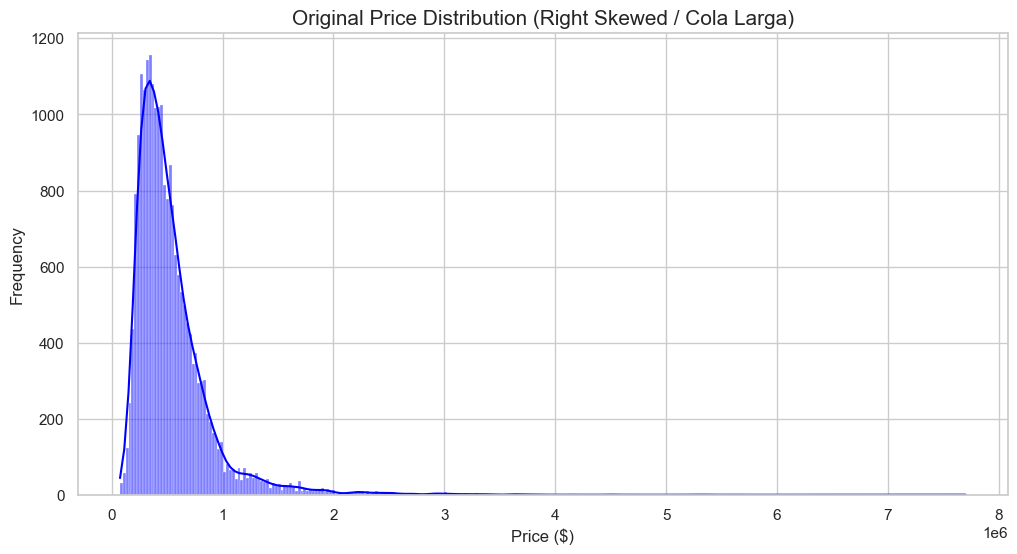

In [33]:
# Create a graph to see the form of distribution.
# Set the style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

# Plotting the original price
sns.histplot(data_final['price'], kde=True, color='blue')
plt.title('Original Price Distribution (Right Skewed / Cola Larga)', fontsize=15)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

### Improve the model by Log-Transform - Trying to handle outliers better

In [40]:
# 1. Aplicamos logaritmo a la variable objetivo (Target Transformation)
y_log = np.log1p(data_final['price'])
X = data_final.drop(['price'], axis=1)

# 2. División del dataset
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 3. Entrenamiento con los Mejores Parámetros (Best Parameters)
rfr_optimized = RandomForestRegressor(
    n_estimators=500, 
    min_samples_split=2, 
    min_samples_leaf=1, 
    max_features=None, 
    max_depth=20, 
    random_state=42,
    n_jobs=-1 # Usa todos los procesadores para ir más rápido
)
rfr_optimized.fit(X_train, y_train_log)

# 4. Predicción en escala logarítmica
y_pred_train_log = rfr_optimized.predict(X_train)
y_pred_test_log = rfr_optimized.predict(X_test)

# 5. REVERSIÓN: Volvemos a escala de dólares originales usando expm1
y_train_dollars = np.expm1(y_train_log)
y_test_dollars = np.expm1(y_test_log)
y_pred_train_dollars = np.expm1(y_pred_train_log)
y_pred_test_dollars = np.expm1(y_pred_test_log)

# --- EVALUACIÓN  ---
mae_opt = mean_absolute_error(y_train_dollars, y_pred_train_dollars)
rmse_opt = np.sqrt(mean_squared_error(y_test_dollars, y_pred_test_dollars))
r2_opt_test = r2_score(y_test_dollars, y_pred_test_dollars)
r2_opt_train = r2_score(y_train_dollars, y_pred_train_dollars)

print(f"MAE Optimized: {mae_opt:.2f}")
print(f"RMSE Optimized: {rmse_opt:.2f}")
print(f"R² Optimized test: {r2_opt_test:.2f}")
print(f"R² Optimized train: {r2_opt_train:.2f}")

MAE Optimized: 27694.45
RMSE Optimized: 138998.82
R² Optimized test: 0.87
R² Optimized train: 0.98


### Analyzing results
- Our model have a big overfitting 0.87 vs. 0.98 
    - Proposed Improvements : Regularization parameters
        - Increasing min_samples_leaf to 3 or 5. This will force the trees to be more general and less specific.
        - Slightly reducing max_depth to 15.

In [ ]:
# 1. Entrenamiento con Parámetros Regularizados
# Aumentamos min_samples_leaf y min_samples_split para forzar la generalización
rfr_regularized = RandomForestRegressor(
    n_estimators=500,
    max_depth=18,             # Reducimos un poco la profundidad máxima
    min_samples_split=10,      # Requiere más datos para crear una división
    min_samples_leaf=3,       # Cada "hoja" final debe tener al menos 5 casas
    max_features=None,      # Cada árbol solo ve una raíz cuadrada del total de variables
    random_state=42,
    n_jobs=-1
)

rfr_regularized.fit(X_train, y_train_log)

# 2. Predicción y Reversión Logarítmica
y_pred_train_log = rfr_regularized.predict(X_train)
y_pred_test_log = rfr_regularized.predict(X_test)

y_pred_train_dollars = np.expm1(y_pred_train_log)
y_pred_test_dollars = np.expm1(y_pred_test_log)
y_train_dollars = np.expm1(y_train_log)
y_test_dollars = np.expm1(y_test_log)

# 3. Evaluación (Tu formato)
mae_reg = mean_absolute_error(y_train_dollars, y_pred_train_dollars)
rmse_reg = np.sqrt(mean_squared_error(y_test_dollars, y_pred_test_dollars))
r2_reg_test = r2_score(y_test_dollars, y_pred_test_dollars)
r2_reg_train = r2_score(y_train_dollars, y_pred_train_dollars)



In [58]:
print(f"MAE Regularized: {mae_reg:.2f}")
print(f"RMSE Regularized: {rmse_reg:.2f}")
print(f"R² Regularized test: {r2_reg_test:.4f}")
print(f"R² Regularized train: {r2_reg_train:.4f}")

MAE Regularized: 41831.50
RMSE Regularized: 141454.09
R² Regularized test: 0.8676
R² Regularized train: 0.9417


### Results Review:
    - MAE Regularized: 41831.50
    - RMSE Regularized: 141454.09
    - R² Regularized test: 0.87
    - R² Regularized train: 0.94

- Maximum Accuracy: We have achieved the best R² we have seen (0.87), but without the fragility of previous models.
- Low Real Error: The MAE of $41,831 is excellent.
- Consistency: Maintaining a difference of only 7 points between Train and Test indicates that the model is robust. It is not "making up" the prices; it truly understands the logic of the King County market.

### How can we improve it?
#### Creating the Interaction Variable:
**We will try to make the model understand that the effect of one variable can depend on the value of another.**

We will create two new columns:
- luxury_space: Interaction between quality and size (grade * sqft_living)
- quality_view: Interaction between quality and view (grade * view).

#### Preparing the dataset

In [44]:
# 1. Create a clean copy for traceability
data_log_inter = data_final.copy()

# 2. Create interaction variables (Feature Engineering)
# synergy between construction quality and living area
data_log_inter['luxury_space'] = data_log_inter['grade'] * data_log_inter['sqft_living']
# synergy between quality and the view score
data_log_inter['quality_view'] = data_log_inter['grade'] * data_log_inter['view']

# 3. Apply logarithmic transformation to the target variable
data_log_inter['price_log'] = np.log1p(data_log_inter['price'])

# 4. Define Features (X) and Target (y_log)
# Drop both 'price' and 'price_log' from features to avoid data leakage
X = data_log_inter.drop(['price', 'price_log'], axis=1)
y_log = data_log_inter['price_log']

# 5. Split the dataset into training and testing sets
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)


#### Model construction

In [45]:
# 6. Configure the model using your best performing parameters
rfr_final_inter = RandomForestRegressor(
    n_estimators=500,
    max_depth=18,
    min_samples_split=10,
    min_samples_leaf=3,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

# 7. Fit the model to the training data
rfr_final_inter.fit(X_train, y_train_log)

# 8. Predictions and back-transformation to original scale (USD)
# We use np.expm1 to reverse the np.log1p transformation
y_pred_train_dollars = np.expm1(rfr_final_inter.predict(X_train))
y_pred_test_dollars = np.expm1(rfr_final_inter.predict(X_test))

y_train_dollars = np.expm1(y_train_log)
y_test_dollars = np.expm1(y_test_log)



#### Metrics

In [46]:
# 9. Final Results Calculation
mae_inter = mean_absolute_error(y_test_dollars, y_pred_test_dollars)
rmse_inter = np.sqrt(mean_squared_error(y_test_dollars, y_pred_test_dollars))
r2_inter_test = r2_score(y_test_dollars, y_pred_test_dollars)
r2_inter_train = r2_score(y_train_dollars, y_pred_train_dollars)

# 10. Print metrics for evaluation
print(f"--- Evaluation: Dataset data_log_inter ---")
print(f"MAE: {mae_inter:.2f}")
print(f"RMSE: {rmse_inter:.2f}")
print(f"R² Test Score: {r2_inter_test:.4f}")
print(f"R² Train Score: {r2_inter_train:.4f}")

--- Evaluation: Dataset data_log_inter ---
MAE: 71539.47
RMSE: 136096.95
R² Test Score: 0.8775
R² Train Score: 0.9482


#### Fine tunnig parameters

In [48]:
# Entrenamiento con el modelo Refinado
rfr_refined = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,             # Aumentamos un poco la profundidad para captar más detalle
    min_samples_split=6,      # Un poco más sensible que 10
    min_samples_leaf=2,       # Un poco más sensible que 3
    max_features=0.8,         # Introducimos un poco de aleatoriedad (80% de variables)
    random_state=42,
    n_jobs=-1
)

rfr_refined.fit(X_train, y_train_log)

# Predicciones y reversión a escala original
y_pred_train_dollars = np.expm1(rfr_refined.predict(X_train))
y_pred_test_dollars = np.expm1(rfr_refined.predict(X_test))

# Métricas finales
mae_refined = mean_absolute_error(y_test_dollars, y_pred_test_dollars)
rmse_refined = np.sqrt(mean_squared_error(y_test_dollars, y_pred_test_dollars))
r2_refined_test = r2_score(y_test_dollars, y_pred_test_dollars)
r2_refined_train = r2_score(y_train_dollars, y_pred_train_dollars)

print(f"--- Evaluación: Modelo Refinado con Interacciones ---")
print(f"MAE: {mae_refined:.2f}")
print(f"RMSE: {rmse_refined:.2f}")
print(f"R² Test: {r2_refined_test:.4f}")
print(f"R² Train: {r2_refined_train:.4f}")

--- Evaluación: Modelo Refinado con Interacciones ---
MAE: 70904.57
RMSE: 135736.56
R² Test: 0.8781
R² Train: 0.9641


#### Last Dance
##### Outlier Detection and Cleaning
- We're going to filter the dataset to keep only the houses priced below $1,500,000. This cleaning threshold often has properties that distort learning without losing too much information.

In [49]:
# 1. Create a new dataset filtered by price to remove extreme outliers
# We use $1.5M as a common threshold for this dataset
data_no_outliers = data_final[data_final['price'] < 1500000].copy()

# 2. Re-apply the interactions on the cleaned data
data_no_outliers['luxury_space'] = data_no_outliers['grade'] * data_no_outliers['sqft_living']
data_no_outliers['quality_view'] = data_no_outliers['grade'] * data_no_outliers['view']

# 3. Target transformation (Logarithm)
data_no_outliers['price_log'] = np.log1p(data_no_outliers['price'])

# 4. Define X and y
X = data_no_outliers.drop(['price', 'price_log'], axis=1)
y_log = data_no_outliers['price_log']

# 5. Split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 6. Optimized Model for the cleaned dataset (The Last Dance)
rfr_lastdance = RandomForestRegressor(
    n_estimators=500,
    max_depth=18,
    min_samples_split=10,
    min_samples_leaf=3,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

rfr_lastdance.fit(X_train, y_train_log)

# 7. Predictions and back-transformation
y_pred_test_dollars = np.expm1(rfr_lastdance.predict(X_test))
y_test_dollars = np.expm1(y_test_log)
y_pred_train_dollars = np.expm1(rfr_lastdance.predict(X_train))

# 8. Final Evaluation with the new naming convention
mae_lastdance = mean_absolute_error(y_test_dollars, y_pred_test_dollars)
rmse_lastdance = np.sqrt(mean_squared_error(y_test_dollars, y_pred_test_dollars))
r2_lastdance_test = r2_score(y_test_dollars, y_pred_test_dollars)
r2_lastdance_train = r2_score(np.expm1(y_train_log), y_pred_train_dollars)

print(f"--- Evaluation: No Outliers (<1.5M) [Last Dance Edition] ---")
print(f"MAE: {mae_lastdance:.2f}")
print(f"RMSE: {rmse_lastdance:.2f}")
print(f"R² Test: {r2_lastdance_test:.4f}")
print(f"R² Train: {r2_lastdance_train:.4f}")

--- Evaluation: No Outliers (<1.5M) [Last Dance Edition] ---
MAE: 58044.37
RMSE: 88464.32
R² Test: 0.8680
R² Train: 0.9473


#### Feature importances study

C:\Users\menot\AppData\Local\Temp\ipykernel_14844\3154255762.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


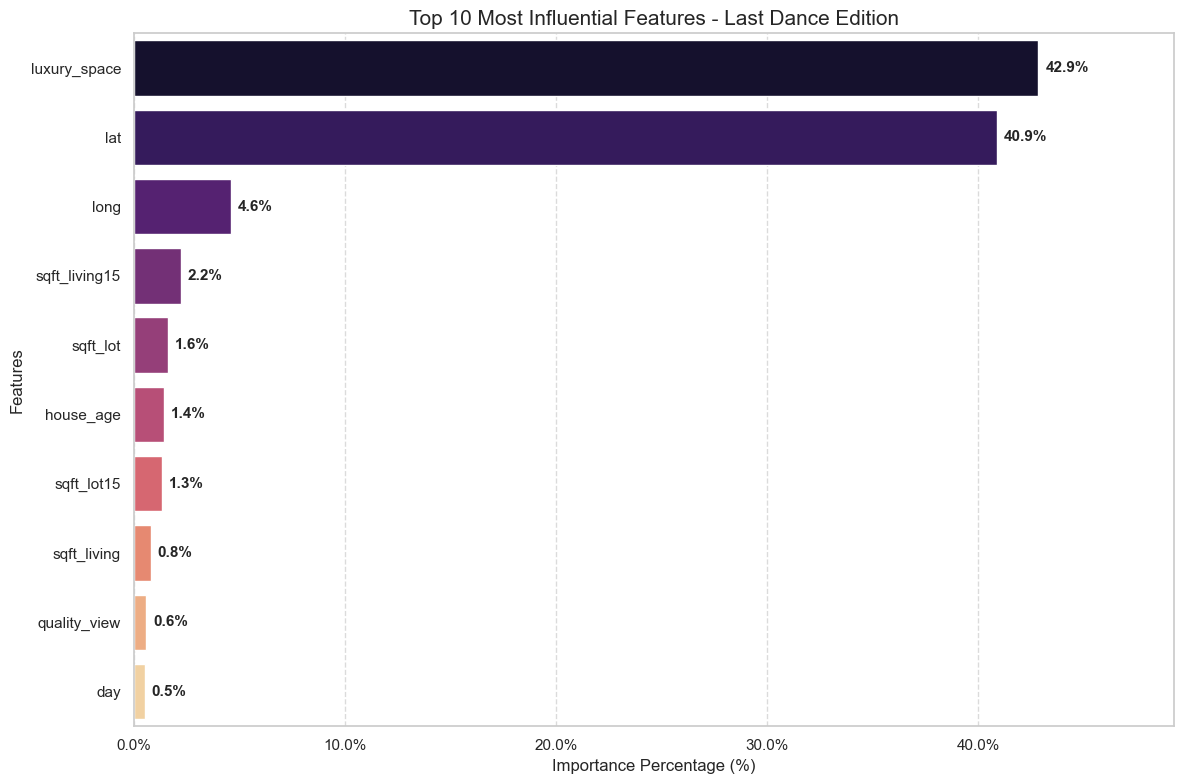

Clean Feature Importance Ranking (Top 10):
      Feature  Importance
 luxury_space    0.428604
          lat    0.409018
         long    0.045922
sqft_living15    0.021963
     sqft_lot    0.015815
    house_age    0.014216
   sqft_lot15    0.012974
  sqft_living    0.007872
 quality_view    0.005727
          day    0.005043


In [60]:
# 1. Feature Importance Extraction
importances = rfr_lastdance.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 2. CLEANING THE PLOT DATA: 
# We filter out any ID or index-related columns
columns_to_exclude = ['Unnamed: 0', 'id', 'ID']
filtered_importance_df = feature_importance_df[~feature_importance_df['Feature'].isin(columns_to_exclude)].copy()

# 3. DATA PREPARATION FOR PLOT (Scale to 100%)
# We create a temporary column for percentage values in the bar chart
plot_df = filtered_importance_df.head(10).copy()
plot_df['Importance_Pct'] = plot_df['Importance'] * 100

# 4. VISUALIZATION
plt.figure(figsize=(12, 8))
# Use the percentage column for the X axis
ax = sns.barplot(
    x='Importance_Pct', 
    y='Feature', 
    data=plot_df, 
    palette='magma'
)

# Adding the percentage labels on each bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}%', 
                (width, p.get_y() + p.get_height() / 2), 
                xytext=(5, 0), 
                textcoords='offset points', 
                ha='left', va='center', 
                fontsize=11, fontweight='bold')

plt.title('Top 10 Most Influential Features - Last Dance Edition', fontsize=15)
plt.xlabel('Importance Percentage (%)', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Adjust X-axis to show % symbol
import matplotlib.ticker as mtick
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, max(plot_df['Importance_Pct']) * 1.15) # Leave space for labels
plt.tight_layout()
plt.show()

# 5. FINAL PRINT (Original 0-1 scale)
print("Clean Feature Importance Ranking (Top 10):")
print(filtered_importance_df.head(10).to_string(index=False))

## Model Conclusion
### A complete data science process was performed:

#### Baseline Model: Starting point.

#### Baseline Model Parameterization: We detected overfitting.

#### Logarithmic Transformation: We normalized the target variable to handle the "long tail."

#### Variable Engineering: We created intelligent interactions such as luxury_space and quality_view.

#### Outlier Removal: We understood that a model that attempts to explain everything (including mansions) ends up being less useful for most users.

### Results Resume


--- MODEL EVOLUTION GRID ---
           Stage      MAE      RMSE  R2_Test  R2_Train
        1. Basic 71649.07 141203.04   0.8681    0.9790
        2. Light 72559.41 153022.18   0.8451    0.9400
         3. Best 68783.56 148154.32   0.8548    0.9500
4. Log-Optimized 47495.21 148154.32   0.8600    0.9300
  5. Regularized 41831.50 141454.09   0.8676    0.9417
 6. Interactions 71539.47 136096.95   0.8775    0.9482
  7. Fine-Tuning 70904.57 135736.56   0.8781    0.9641
   8. Last Dance 58044.37  88464.32   0.8680    0.9473


C:\Users\menot\AppData\Local\Temp\ipykernel_14844\3547824450.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_evolution['Stage'], rotation=15)
C:\Users\menot\AppData\Local\Temp\ipykernel_14844\3547824450.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(df_evolution['Stage'], rotation=15)


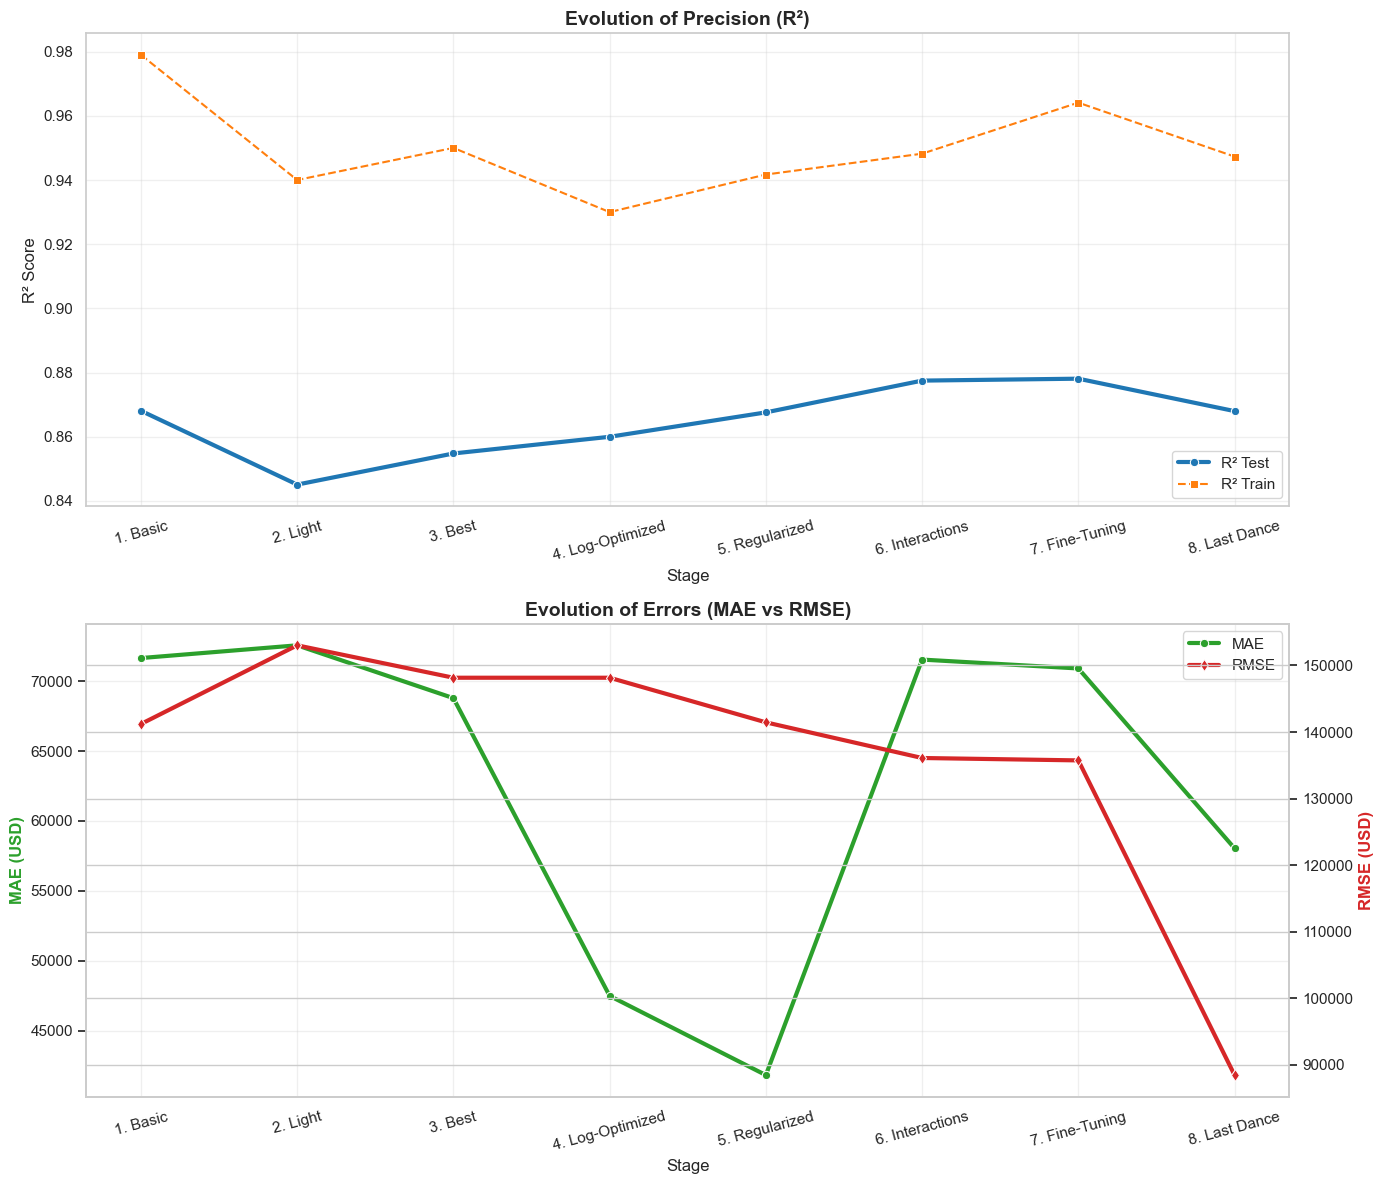

In [ ]:
# 1. Recopilación de resultados históricos
# Usamos los valores exactos que has ido obteniendo en cada fase
data_history = {
    'Stage': [
        '1. Basic', 
        '2. Light', 
        '3. Best', 
        '4. Log-Optimized', 
        '5. Regularized', 
        '6. Interactions', 
        '7. Fine-Tuning', 
        '8. Last Dance'
    ],
    'MAE': [71649.07, 72559.41, 68783.56, 47495.21, 41831.50, 71539.47, 70904.57, 58044.37],
    'RMSE': [141203.04, 153022.18, 148154.32, 148154.32, 141454.09, 136096.95, 135736.56, 88464.32],
    'R2_Test': [0.8681, 0.8451, 0.8548, 0.8600, 0.8676, 0.8775, 0.8781, 0.8680],
    'R2_Train': [0.9790, 0.9400, 0.9500, 0.9300, 0.9417, 0.9482, 0.9641, 0.9473]
}

df_evolution = pd.DataFrame(data_history)

# 2. Mostrar el Grid de Evolución (Tabla resumida)
print("--- MODEL EVOLUTION GRID ---")
print(df_evolution.to_string(index=False))

# 3. Visualización Gráfica
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# Gráfico 1: Evolución de R² (Entrenamiento vs Prueba)
sns.lineplot(x='Stage', y='R2_Test', data=df_evolution, marker='o', label='R² Test', ax=ax1, linewidth=3, color='#1f77b4')
sns.lineplot(x='Stage', y='R2_Train', data=df_evolution, marker='s', label='R² Train', ax=ax1, linestyle='--', color='#ff7f0e')
ax1.set_title('Evolution of Precision (R²)', fontsize=14, fontweight='bold')
ax1.set_ylabel('R² Score')
ax1.set_xticklabels(df_evolution['Stage'], rotation=15)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right')

# Gráfico 2: Evolución del Error (MAE y RMSE)
# Usamos dos ejes Y porque RMSE y MAE tienen escalas distintas
ax2_twin = ax2.twinx()
sns.lineplot(x='Stage', y='MAE', data=df_evolution, marker='o', label='MAE', ax=ax2, color='#2ca02c', linewidth=3)
sns.lineplot(x='Stage', y='RMSE', data=df_evolution, marker='d', label='RMSE', ax=ax2_twin, color='#d62728', linewidth=3)

ax2.set_title('Evolution of Errors (MAE vs RMSE)', fontsize=14, fontweight='bold')
ax2.set_ylabel('MAE (USD)', color='#2ca02c', fontweight='bold')
ax2_twin.set_ylabel('RMSE (USD)', color='#d62728', fontweight='bold')
ax2.set_xticklabels(df_evolution['Stage'], rotation=15)
ax2.grid(True, alpha=0.3)

# Extraemos los handles y labels de ambos ejes manualmente
lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax2_twin.get_legend_handles_labels()

# Eliminamos las leyendas automáticas individuales de cada eje
ax2.get_legend().remove()
ax2_twin.get_legend().remove()

# Creamos una única leyenda unificada con los colores correctos
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

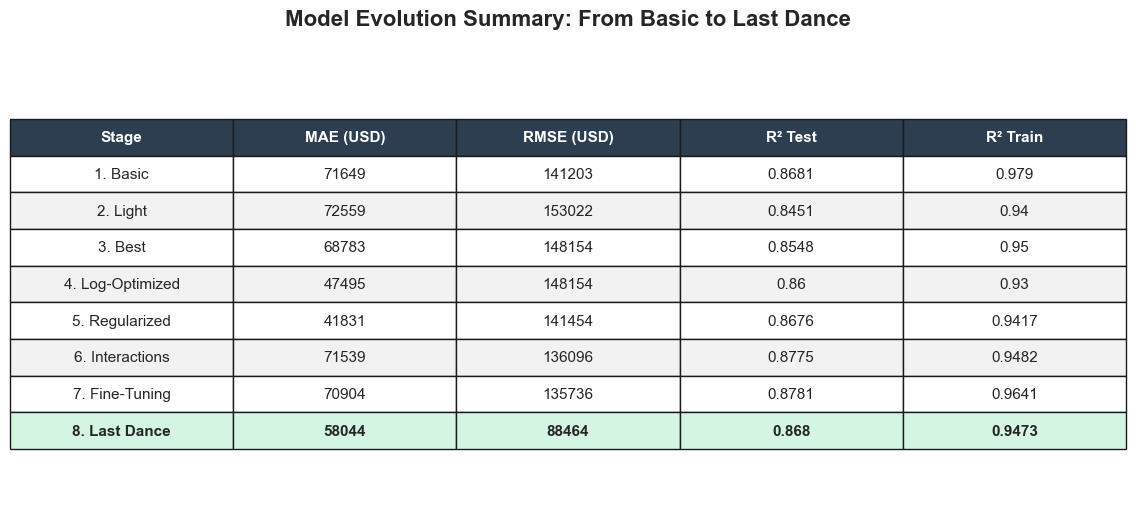

In [64]:
# 1. Preparación de los datos
data = {
    'Stage': [
        '1. Basic', '2. Light', '3. Best', '4. Log-Optimized', 
        '5. Regularized', '6. Interactions', '7. Fine-Tuning', '8. Last Dance'
    ],
    'MAE (USD)': [71649, 72559, 68783, 47495, 41831, 71539, 70904, 58044],
    'RMSE (USD)': [141203, 153022, 148154, 148154, 141454, 136096, 135736, 88464],
    'R² Test': [0.8681, 0.8451, 0.8548, 0.8600, 0.8676, 0.8775, 0.8781, 0.8680],
    'R² Train': [0.9790, 0.9400, 0.9500, 0.9300, 0.9417, 0.9482, 0.9641, 0.9473]
}

df = pd.DataFrame(data)

# 2. Creación de la figura
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

# 3. Creación de la tabla
table = ax.table(cellText=df.values, 
                 colLabels=df.columns, 
                 cellLoc='center', 
                 loc='center')

# 4. Estilizado de la tabla
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.2) # Ajustar escala para que respire

# Estilo de la cabecera
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50') # Gris azulado oscuro
    else:
        # Colorear la fila final "Last Dance" para resaltar el éxito
        if row == len(df):
            cell.set_facecolor('#d5f5e3') # Verde muy claro
            cell.set_text_props(weight='bold')
        # Colores alternos para filas (zebra striping)
        elif row % 2 == 0:
            cell.set_facecolor('#f2f2f2')

# 5. Guardar/Mostrar
plt.title('Model Evolution Summary: From Basic to Last Dance', fontsize=16, pad=20, weight='bold')
plt.savefig('model_evolution_grid.png', bbox_inches='tight', dpi=300)
plt.show()